In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import numpy as np
import scipy
import pandas as pd
from scipy.stats import pearsonr, zscore

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# from PSN.psn import psn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

sys.path.append('/home/ri99/ieeg/scripts')
from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, ncsnr_figs

# Set random seed for reproducibility
np.random.seed(42)

In [8]:
base_dir = '/home/ri99/ieeg/data'
ieeg_dir = f'{base_dir}/subjects/111/'
csv_dir = f'{base_dir}/nsd_PTB'
img_dir = f'{base_dir}/nsd_ecog'
cache_dir = f'{base_dir}/.cache'
os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

In [9]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
# labels = metapath_df['Destrieux_label_text'].values
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [10]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [11]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz

run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    data = np.load(f"{ieeg_dir}/trace1024/npy/sub1{sub}_NSD_run{run}_epo.npy")
    labels = pd.read_csv(f"{ieeg_dir}/trace1024/ch_labels/sub1{sub}_NSD_run{run}_channels.csv")
    time = np.load(f"{ieeg_dir}/trace1024/time/sub1{sub}_NSD_run{run}_time.npy")

    assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
    assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"

    # assert labels['channel_name'].iloc[168] == 'ECG1'
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    all_data.append(data)
    all_labels.append(labels)

100%|██████████| 56/56 [00:18<00:00,  3.09it/s]


In [12]:
# combine data across runs while dealing with some runs not having data from the same channels
data, channel_info = align_channels_across_runs(all_data, all_labels)
print(data.dtype)
data = data.transpose(1,2,0).astype(np.float32)  # convert to channels x time x trials
print(f"Final shape: {data.shape}, {data.dtype}")
print(channel_info.head())

Aligning runs: 100%|██████████| 56/56 [00:08<00:00,  6.82it/s]



Channels with missing data (not present in all runs): ['LAP-pC_2-1', 'LmF-aI_6-5', 'LmF-aI_7-6', 'LsT-HC_2-1', 'LsT-HC_3-2', 'LsT-HC_5-4', 'LsT-HC_6-5', 'LsT-HC_8-7', 'LsT-Pu_6-5', 'LsT-Pu_7-6', 'LsT-Pu_8-7', 'RSP-pC_11-10', 'RSP-pC_12-11', 'RSP-pC_5-4', 'RSP-pC_6-5', 'RSP-pC_8-7', 'RSP-pC_9-8', 'RmF-aI_10-9', 'RmF-aI_11-10', 'RmF-aI_12-11', 'RmF-aI_6-5', 'RmF-oF_5-4', 'RmF-oF_8-7']
Inserted NaNs for missing data.
float32
Final shape: (130, 2254, 5600), float32
   channel_name  channel_idx
0   LAP-pC_10-9            9
1  LAP-pC_11-10           10
2  LAP-pC_12-11           11
3    LAP-pC_2-1            1
4    LAP-pC_3-2            2


In [13]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#     display(channel_info)
# print(labels.iloc[124:130])

# reshape to identify repeated stimuli

In [14]:
# First, reshape your electrode data using the existing function
reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
    data,  # Your electrode data (channels, time, trials)
    curric,         # Your events dataframe
    stim_column='coco_id'
)

Original electrode data shape: (130, 2254, 5600)
Events dataframe shape: (5600, 7)
Number of unique stimuli: 2900
Maximum repetitions per stimulus: 4
Repetition distribution:
count
1     800
2    1600
3     400
4     100
Name: count, dtype: int64


100%|██████████| 2900/2900 [00:03<00:00, 915.39it/s] 

Final reshaped data shape: (130, 2900, 2254, 4)
Shape interpretation: (130 channels, 2900 images, 2254 timepoints, 4 max repeats)


In [15]:
reshaped_electrode_data.shape

(130, 2900, 2254, 4)

# measure NCSNR and noise ceiling pct over time to identify electrodes with good signal 

Transposed data shape: (2900, 130, 4, 2254)
Shape interpretation: (2900 conditions/images, 130 channels, 4 trials/repeats, 2254 timepoints)
Computing NCSNR for 130 channels across 2254 timepoints...
Processing timepoint 1/2254 (-0.2ms)


/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:113: RuntimeWarning: Degrees of freedom <= 0 for slice.
  trial_var = np.nanvar(data_in, axis=2, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:117: RuntimeWarning: Mean of empty slice
  data_var = np.nanvar(np.nanmean(data_in, axis=2), axis=1, ddof=1)
/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/utils.py:120: RuntimeWarning: divide by zero encountered in divide
  n_eff_inv = np.nanmean(np.where(n_per_cond > 0, 1.0 / n_per_cond, np.nan), axis=1)  # (channels,)


Processing timepoint 101/2254 (-0.1ms)
Processing timepoint 201/2254 (-0.0ms)
Processing timepoint 301/2254 (0.1ms)
Processing timepoint 401/2254 (0.2ms)
Processing timepoint 501/2254 (0.3ms)
Processing timepoint 601/2254 (0.4ms)
Processing timepoint 701/2254 (0.5ms)
Processing timepoint 801/2254 (0.6ms)
Processing timepoint 901/2254 (0.7ms)
Processing timepoint 1001/2254 (0.8ms)
Processing timepoint 1101/2254 (0.9ms)
Processing timepoint 1201/2254 (1.0ms)
Processing timepoint 1301/2254 (1.1ms)
Processing timepoint 1401/2254 (1.2ms)
Processing timepoint 1501/2254 (1.3ms)
Processing timepoint 1601/2254 (1.4ms)
Processing timepoint 1701/2254 (1.5ms)
Processing timepoint 1801/2254 (1.6ms)
Processing timepoint 1901/2254 (1.7ms)
Processing timepoint 2001/2254 (1.8ms)
Processing timepoint 2101/2254 (1.9ms)
Processing timepoint 2201/2254 (1.9ms)
NCSNR computation complete!
NCSNR results shape: (100, 2254)
NC results shape: (100, 2254)


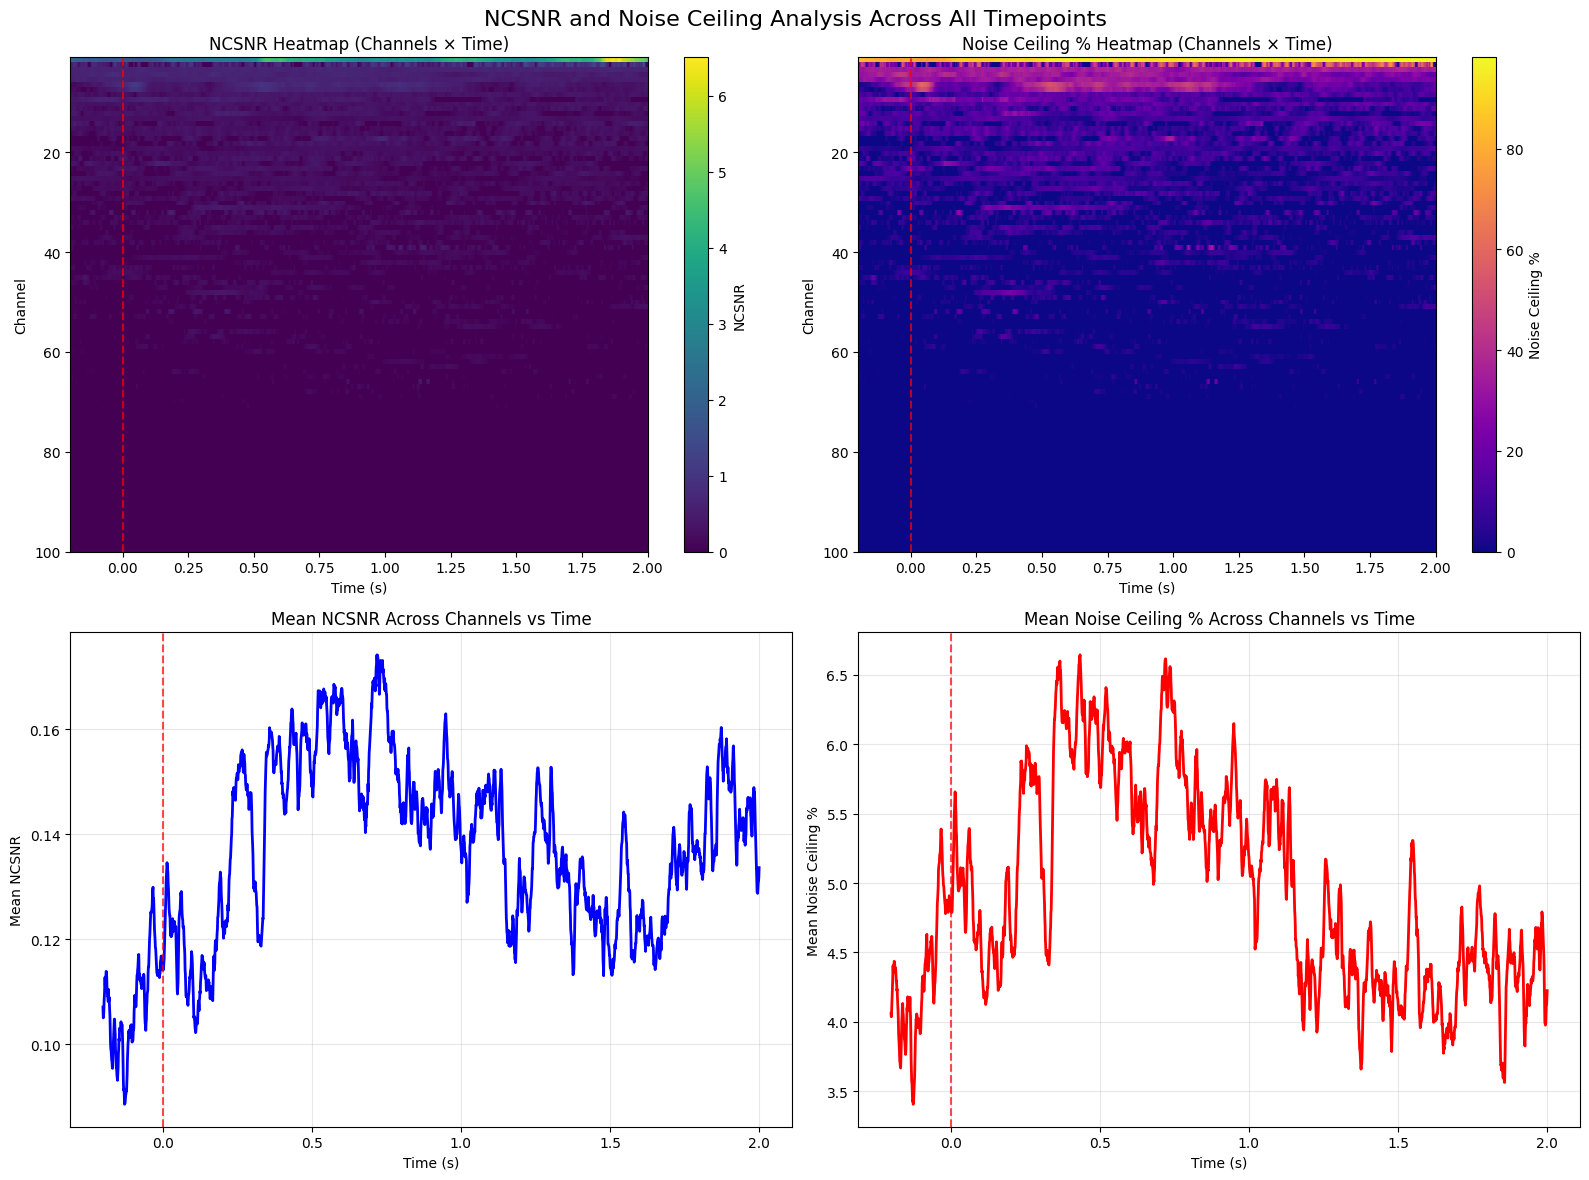


Summary Statistics:
Mean NCSNR across all channels and time: 0.136
Max NCSNR: 6.505
Mean Noise Ceiling across all channels and time: 4.9%
Max Noise Ceiling: 98.1%
Peak NCSNR time: 0.7ms
Peak NC time: 0.4ms


In [11]:
# Transpose from (channels, images, time, repeats) to (images, channels, repeats, time)
# data_rep = filtered_3_repeats.transpose(1, 0, 3, 2)
data_slim = reshaped_electrode_data.transpose(1, 0, 3, 2)
print(f"Transposed data shape: {data_slim.shape}")
print(f"Shape interpretation: ({data_slim.shape[0]} conditions/images, {data_slim.shape[1]} channels, {data_slim.shape[2]} trials/repeats, {data_slim.shape[3]} timepoints)")

# Compute NCSNR for all timepoints
ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_slim, time)

rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
ncsnr_figs(ncsnr_all[rankings[:100]], nc_all[rankings[:100]], time, save_path='ncsnr_voltage')

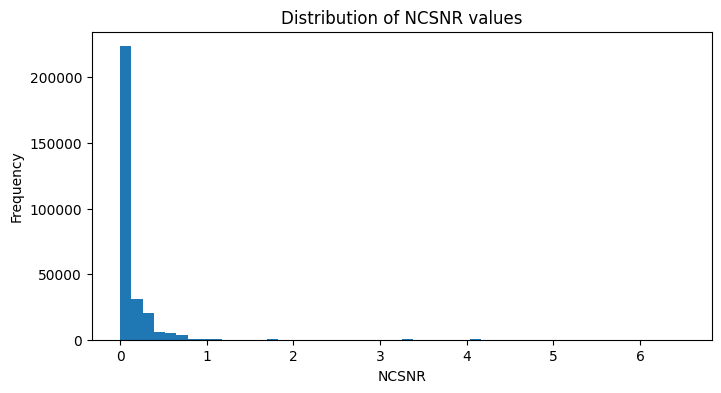

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(ncsnr_all.flatten(), bins=50)
plt.title("Distribution of NCSNR values")
plt.xlabel("NCSNR")
plt.ylabel("Frequency")
plt.show()

In [13]:
# calculate average response of each channel
print(reshaped_electrode_data.shape)

baseline_start_idx = int(np.floor(baseline_time+0.2 * sampling_rate))  # baseline duration (sec; -0.2-0.2sec post stim onset) * sampling rate (1/sec)
baseline_mean = np.mean(reshaped_electrode_data[:,:,:baseline_start_idx,:], axis=2, dtype=np.float32)
for i in range(reshaped_electrode_data.shape[2]):
    reshaped_electrode_data[:, :, i, :] -= baseline_mean  # baseline subtract per trial, perform in-place to avoid extra memory usage

(130, 2900, 2254, 4)


In [14]:
avg_signal = np.nanmean(reshaped_electrode_data, axis=3, dtype=np.float32)
del reshaped_electrode_data  # clear space
avg_signal = np.nanmean(avg_signal, axis=1, dtype=np.float32)
print(avg_signal.shape)

/tmp/ipykernel_828593/3123017074.py:1: RuntimeWarning: Mean of empty slice
  avg_signal = np.nanmean(reshaped_electrode_data, axis=3, dtype=np.float32)


(130, 2254)


Plotting...


100%|██████████| 130/130 [00:09<00:00, 14.03it/s]


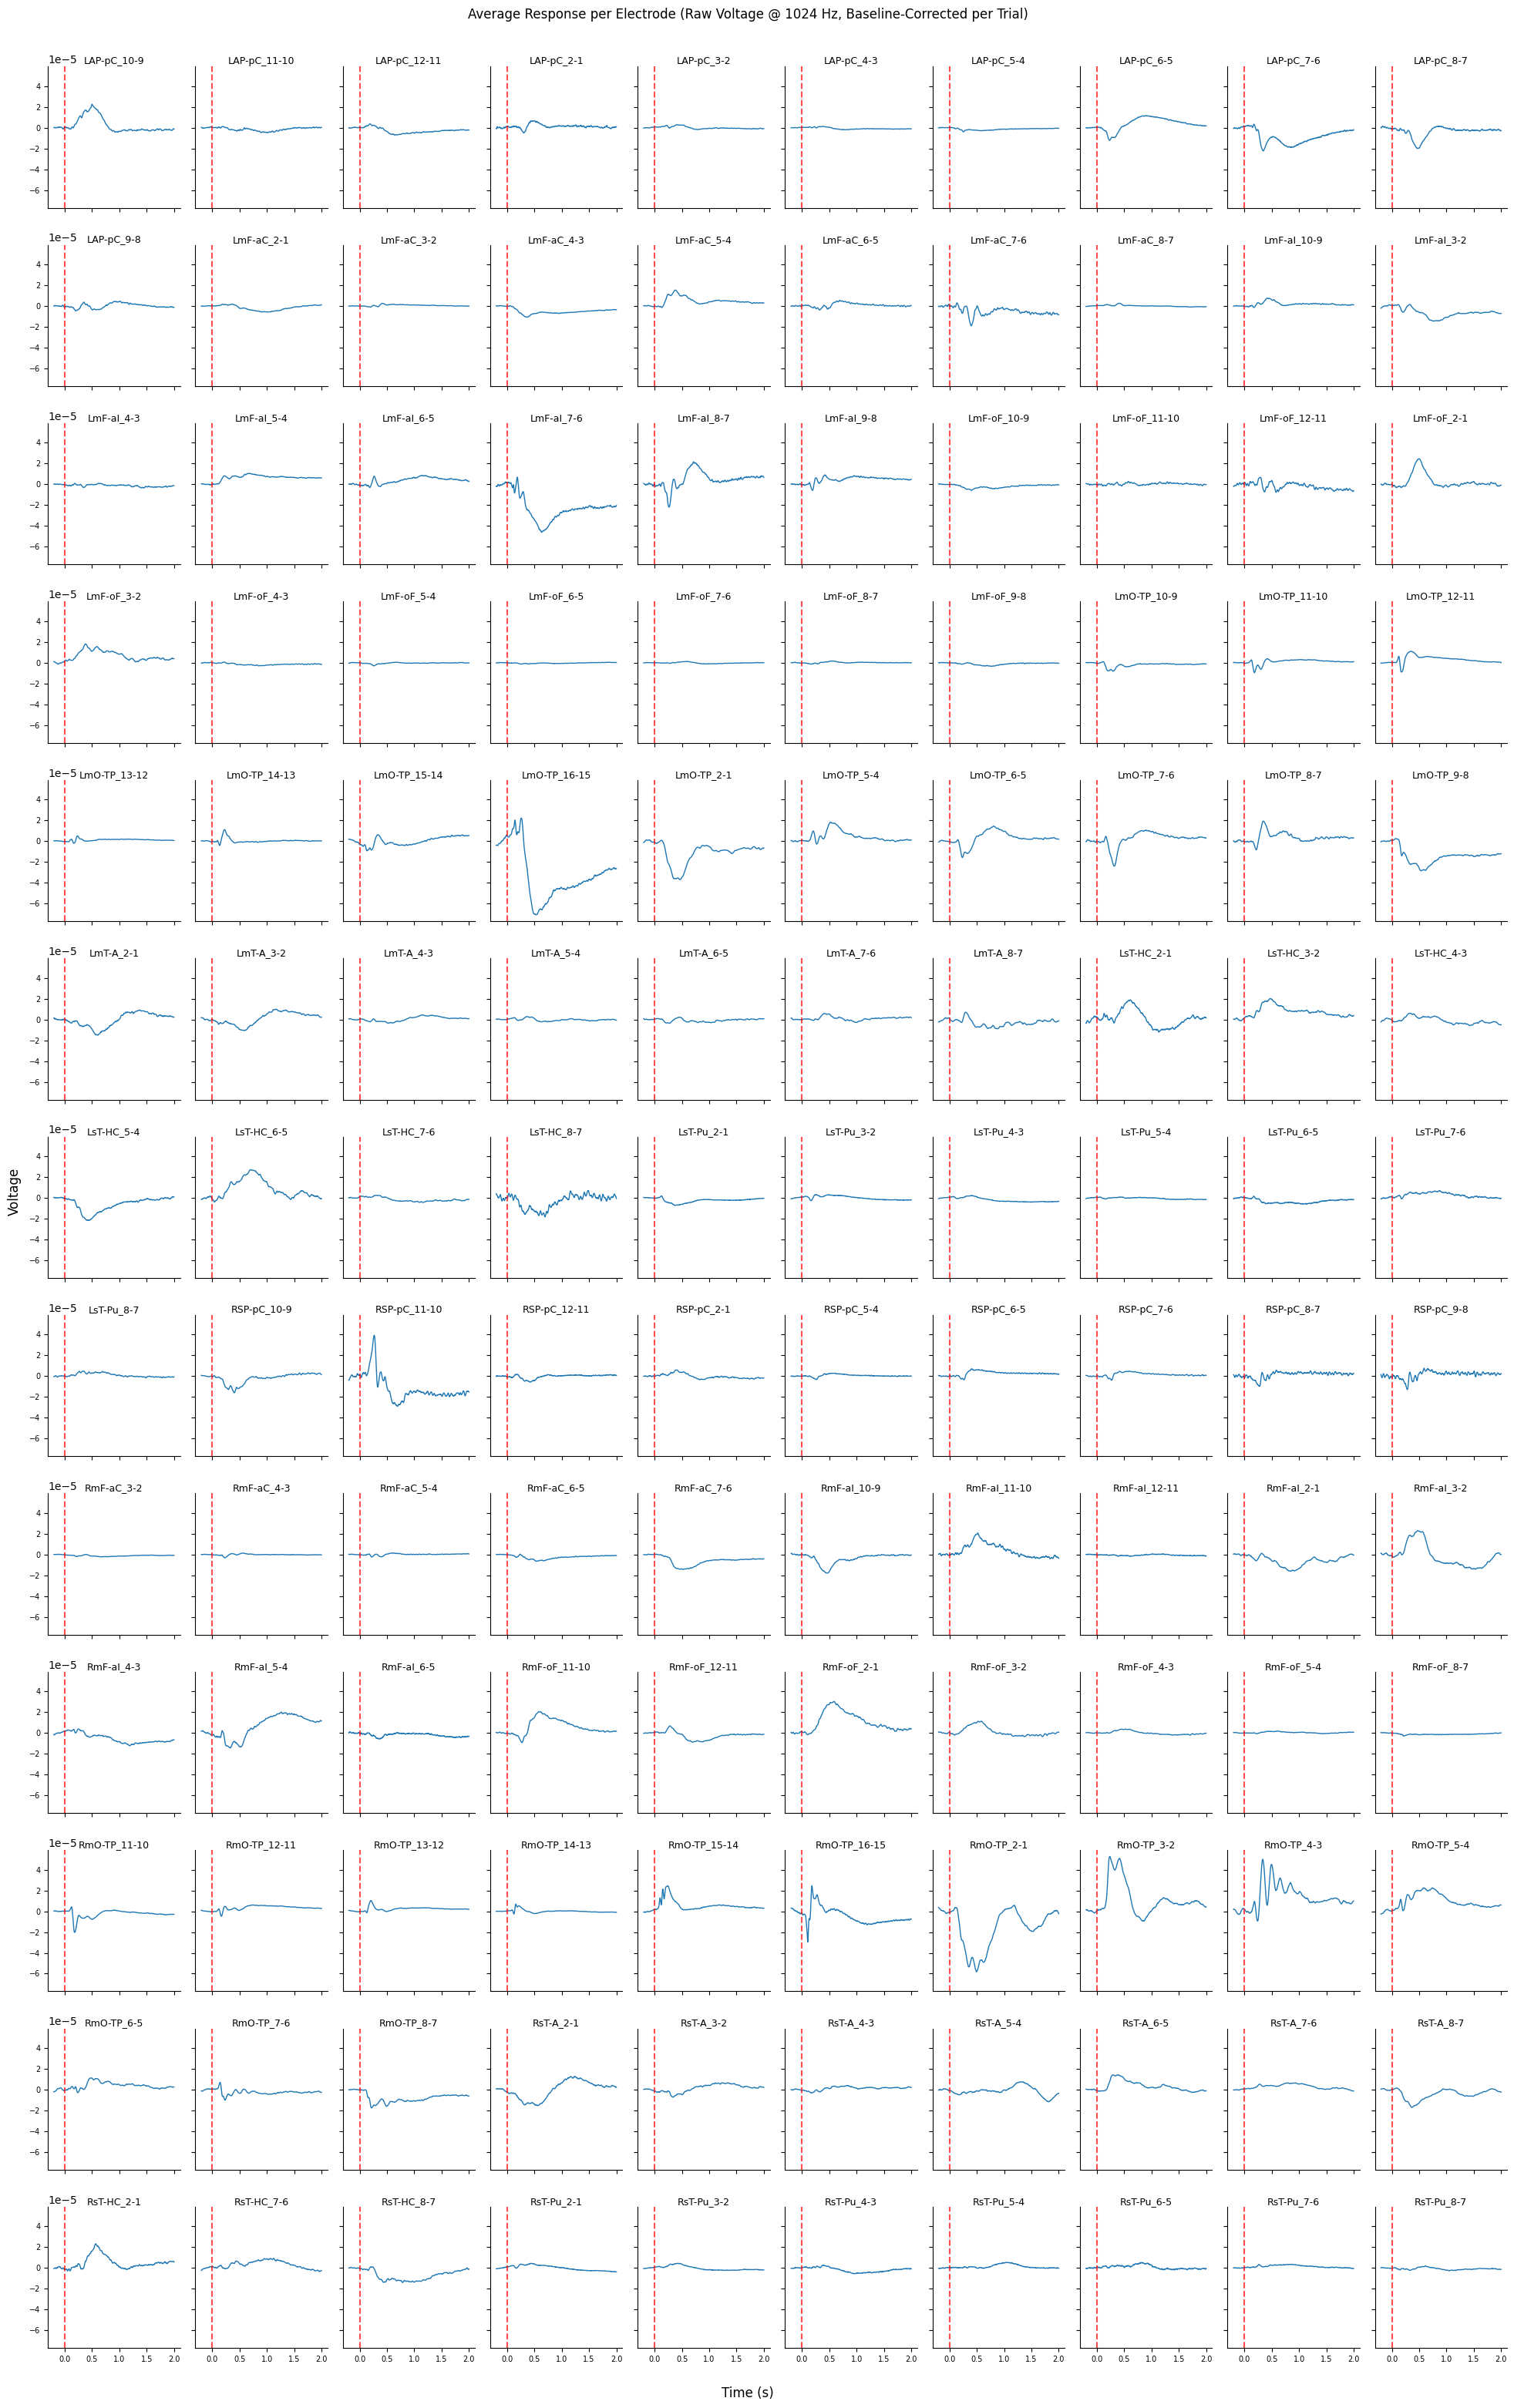

In [15]:
ncols = 10
nrows = int(np.ceil(len(avg_signal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 32), sharex=True, sharey=True)
fig.suptitle(f'Average Response per Electrode (Raw Voltage @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
fig.supxlabel('Time (s)')
fig.supylabel('Voltage')
axes_flat = axes.flatten()

print('Plotting...')
for i in tqdm(range(len(avg_signal))):
    ax = axes_flat[i]
    ax.plot((np.arange(avg_signal.shape[1])/sampling_rate)-baseline_time, avg_signal[i], linewidth=1)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    curr_label = channel_info.iloc[i]
    # if int(curr_label['channel_idx']) in rankings[:20]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='red', fontweight='bold')
    # elif int(curr_label['channel_idx']) in rankings[20:50]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='orange')
    # else:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    
    ax.tick_params(labelsize=7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
plt.savefig('avg_response')
plt.show()

In [16]:
display(channel_info.iloc[rankings[:50]]['channel_name'])

73     RSP-pC_12-11
3        LAP-pC_2-1
99       RmF-oF_8-7
69       LsT-Pu_7-6
98       RmF-oF_5-4
22       LmF-aI_6-5
23       LmF-aI_7-6
75       RSP-pC_5-4
68       LsT-Pu_6-5
94     RmF-oF_12-11
87     RmF-aI_12-11
60       LsT-HC_5-4
117       RsT-A_6-5
57       LsT-HC_2-1
15       LmF-aC_6-5
16       LmF-aC_7-6
86     RmF-aI_11-10
72     RSP-pC_11-10
53        LmT-A_5-4
14       LmF-aC_5-4
76       RSP-pC_6-5
58       LsT-HC_3-2
0       LAP-pC_10-9
61       LsT-HC_6-5
118       RsT-A_7-6
13       LmF-aC_4-3
44       LmO-TP_2-1
92       RmF-aI_6-5
93     RmF-oF_11-10
63       LsT-HC_8-7
43     LmO-TP_16-15
79       RSP-pC_9-8
129      RsT-Pu_8-7
127      RsT-Pu_6-5
47       LmO-TP_7-6
12       LmF-aC_3-2
96       RmF-oF_3-2
24       LmF-aI_8-7
74       RSP-pC_2-1
108      RmO-TP_4-3
29       LmF-oF_2-1
124      RsT-Pu_3-2
126      RsT-Pu_5-4
59       LsT-HC_4-3
77       RSP-pC_7-6
1      LAP-pC_11-10
56        LmT-A_8-7
45       LmO-TP_5-4
2      LAP-pC_12-11
125      RsT-Pu_4-3


Plotting...


100%|██████████| 50/50 [00:00<00:00, 56.99it/s]


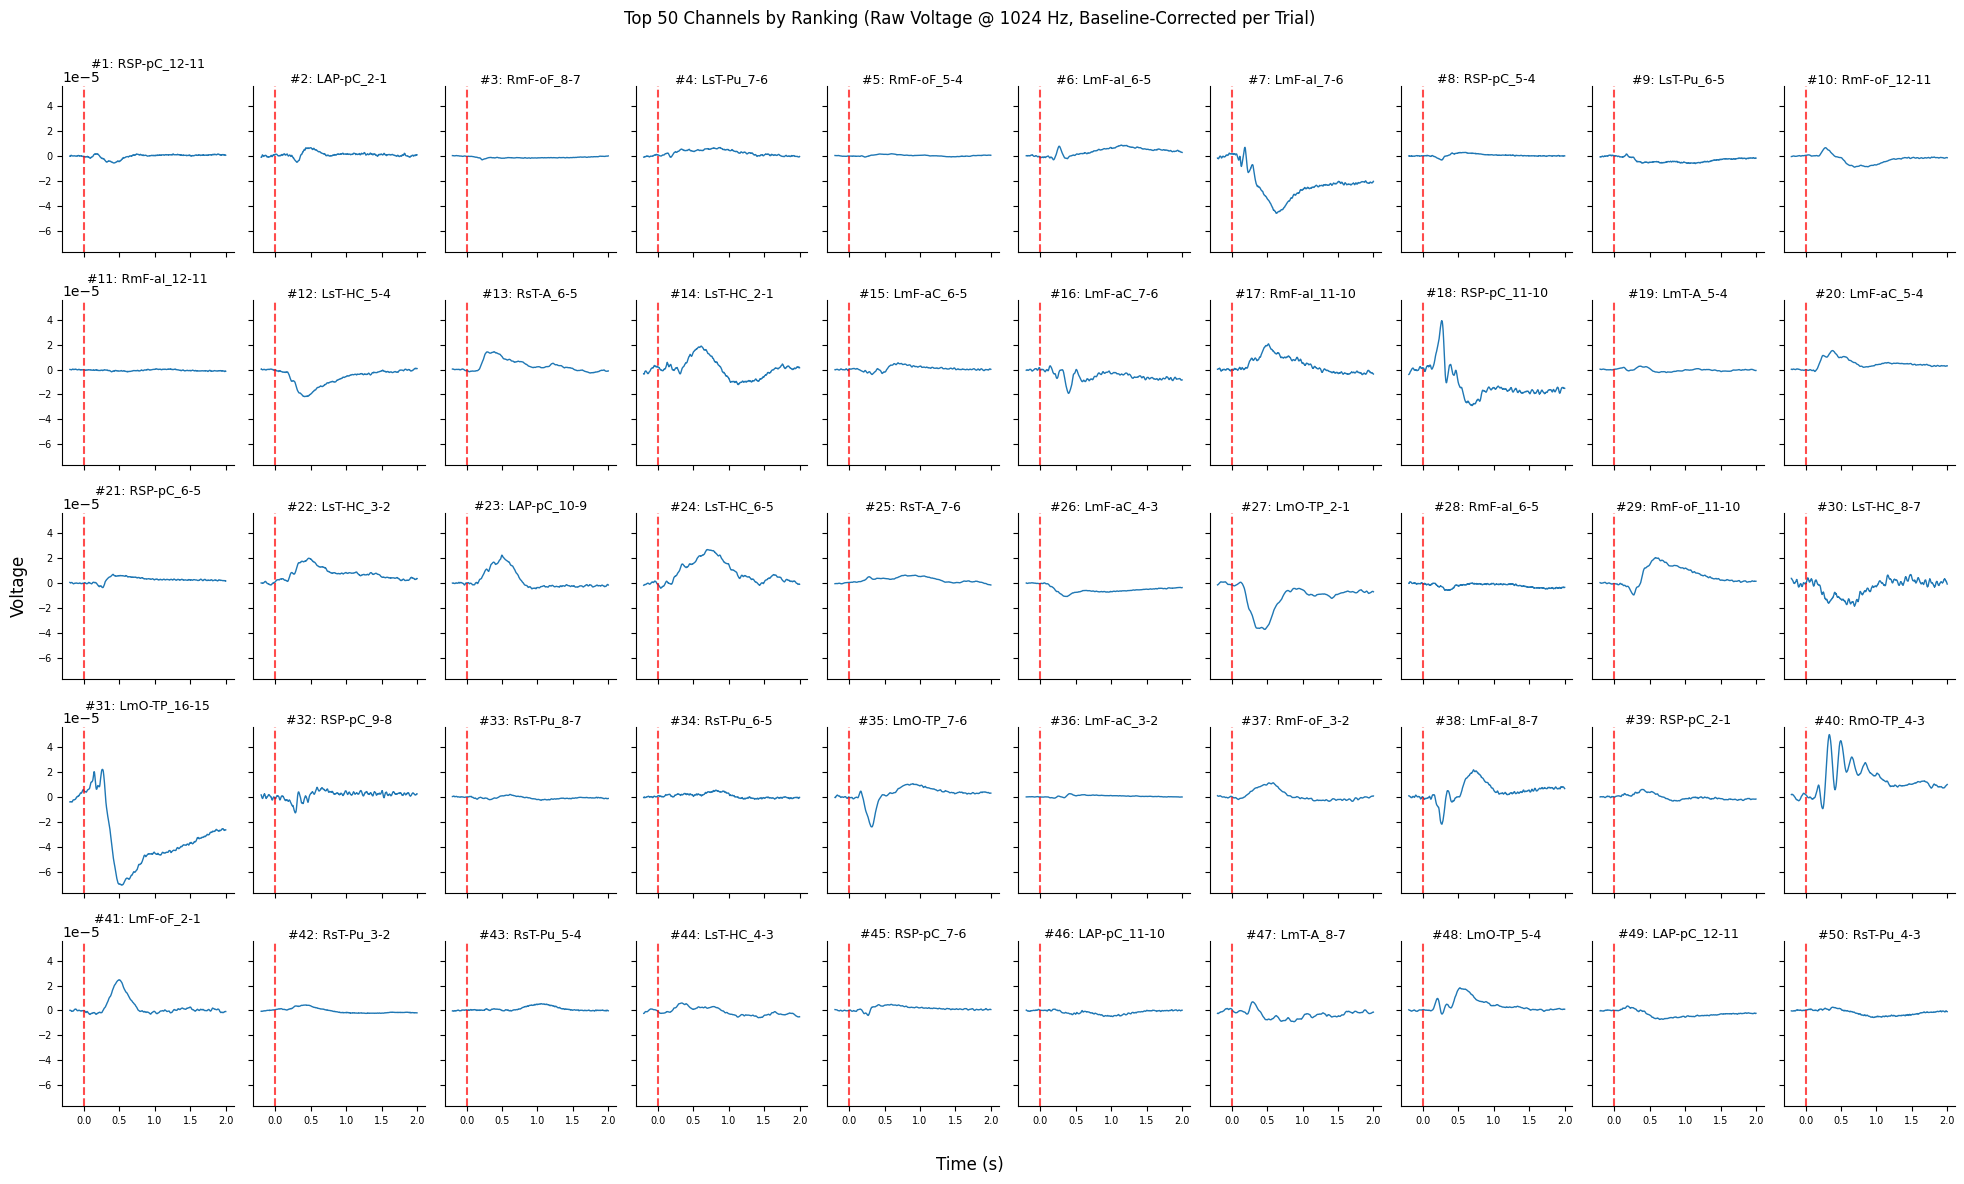

In [17]:
k = 50  # top-k channels
top_k_indices = rankings[:k]

ncols = 10
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12), sharex=True, sharey=True)
fig.suptitle(f'Top {k} Channels by Ranking (Raw Voltage @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
fig.supxlabel('Time (s)')
fig.supylabel('Voltage')
axes_flat = axes.flatten()

print('Plotting...')
for plot_idx, channel_idx in enumerate(tqdm(top_k_indices)):
    ax = axes_flat[plot_idx]
    ax.plot((np.arange(avg_signal.shape[1])/sampling_rate)-baseline_time, avg_signal[channel_idx], linewidth=1)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    curr_label = channel_info.iloc[channel_idx]
    ax.set_title(f"#{plot_idx+1}: {curr_label['channel_name']}", fontsize=9, pad=2)
    
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for idx in range(k, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
plt.savefig('avg_response_top50')
plt.show()